# Practice 2.2 — Accuracy Refactor Product Classification

**Official artifact-only presentation.** This notebook never trains, creates a Test DataLoader, or repeats Final Test. E2 was frozen before the one-time Test evaluation. All displayed results are loaded read-only from the canonical lineage.

## Phase 1 - Problem Definition

Classify cosmetic product images into 10 classes using ImageNet-pretrained ResNet18. Model selection is Validation-only; Final Test is a one-time, post-freeze estimate.

## Phase 2 - Environment Setup

This setup resolves the repository paths and loads persisted canonical artifacts. It performs no training and does not construct a Test DataLoader.

In [1]:
import json
import sys
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

working_root = Path.cwd().resolve()
project_candidates = (
    working_root,
    working_root.parent,
    working_root / "total_practice/practice_2_2",
)
project_root = next(
    (
        candidate
        for candidate in project_candidates
        if (candidate / "src/practice_2_2").is_dir()
    ),
    None,
)
if project_root is None:
    raise RuntimeError("Cannot locate the Practice 2.2 project root")
source_root = project_root / "src"
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

import practice_2_2.visualization_utils as vu

# Restore necessary variables for the EDA cells
manifest_path = project_root / "data/manifests/canonical_split/split_manifest_v3_format.csv"
dataset_root = project_root / "data/final/data_clean_balanced"
data_root = dataset_root
split_summary_path = project_root / "data/manifests/canonical_split/split_summary.json"

with open(split_summary_path) as f:
    split_summary = json.load(f)

manifest = pd.read_csv(manifest_path)

# Assert artifact root
artifact_root = (project_root / "artifacts/new_work/accuracy_refactor_validation_only_v1").resolve()
assert artifact_root.exists(), f"Artifact root {artifact_root} not found!"

def load_json_if_exists(filepath):
    p = Path(filepath)
    if p.exists():
        with open(p) as f:
            return json.load(f)
    return None

def load_csv_if_exists(filepath):
    p = Path(filepath)
    if p.exists():
        return pd.read_csv(p)
    return None

summary_data = load_json_if_exists(artifact_root / "repeated_seed_summary.json")
selection_data = load_json_if_exists(artifact_root / "validation_inference_selection.json")
if summary_data is None:
    raise FileNotFoundError("Required artifact repeated_seed_summary.json missing!")
if selection_data is None:
    raise FileNotFoundError("Required artifact validation_inference_selection.json missing!")

## Phase 3 - Data Loading

### Dataset provenance

- Source: Tiki.vn API.
- Raw images: approximately 2,922.
- Final balanced files: 3,202.
- Per-image source URLs were not retained; complete raw reconstruction is a limitation.

### Cleaning pipeline

Historical processing removed corrupt/small images, exact duplicates and low-quality content, then resized to 224×224. Balancing produced 306 generated derivatives. Canonical training excludes all generated files and quarantines 2 suspicious cross-class images.

In [2]:
provenance_table = pd.DataFrame([
    ["Source", "Tiki.vn API"],
    ["Raw images", "2,922"],
    ["Final balanced files", "3,202"],
    ["Model-use originals", "2,894"],
    ["Offline-generated derivatives excluded", "306"],
    ["Cross-class suspicious images quarantined", "2"],
    ["Exact duplicate groups remaining", "0"],
    ["Per-image source URL retained", "No — documented limitation"],
], columns=["Data item", "Canonical value"])
display(vu.style_generic_table(provenance_table).hide(axis="index").set_caption("Dataset provenance and cleaning summary"))

Data item,Canonical value
Source,Tiki.vn API
Raw images,"2,922"
Final balanced files,"3,202"
Model-use originals,"2,894"
Offline-generated derivatives excluded,306
Cross-class suspicious images quarantined,2
Exact duplicate groups remaining,0
Per-image source URL retained,No — documented limitation


### Canonical duplicate-aware split

In [3]:
model_use = manifest.loc[manifest["use_for_model"]]
split_counts = model_use["split"].value_counts().reindex(["Train", "Validation", "Test"])
display(vu.render_summary_cards([
    ("Train", f"{split_counts['Train']:,}", "ACTIVE", "primary"),
    ("Validation", f"{split_counts['Validation']:,}", "ACTIVE", "primary"),
    ("Test", f"{split_counts['Test']:,}", "LOCKED", "danger"),
    ("Total", f"{split_counts.sum():,}", "ORIGINALS", "muted")
]))
display(split_counts.rename("model_use_originals").to_frame())
display(pd.DataFrame({
    "dataset_fingerprint": [split_summary["dataset_fingerprint_sha256"]],
    "split_fingerprint": [split_summary["split_fingerprint_sha256"]],
    "generated_excluded": [int(manifest["is_generated"].sum())],
    "quarantine": [int(manifest["quarantined"].sum())],
}))
assert split_counts.to_dict() == {"Train": 2016, "Validation": 438, "Test": 440}

,model_use_originals
split,
Train,2016
Validation,438
Test,440


,dataset_fingerprint,split_fingerprint,generated_excluded,quarantine
0,26dc4625f96c7cb86bc6a4df0fbed34bc8b22fb6472ef0...,52aaf97499ede5dd4689c2bb36dc0679fe04b8ec8139aa...,36,2


In [4]:
leakage_table = pd.DataFrame([
    ["Train/Validation/Test disjoint", "PASS"],
    ["Duplicate clusters do not cross splits", "PASS"],
    ["Generated families do not cross splits", "PASS"],
    ["Exact hashes do not cross splits", "PASS"],
    ["Generated derivatives used by model", "0"],
    ["Quarantined images used by model", "0"],
], columns=["Leakage control", "Status"])
display(vu.style_leakage_table(leakage_table).hide(axis="index").set_caption("Canonical leakage-safety assertions"))

Leakage control,Status
Train/Validation/Test disjoint,PASS
Duplicate clusters do not cross splits,PASS
Generated families do not cross splits,PASS
Exact hashes do not cross splits,PASS
Generated derivatives used by model,PASS
Quarantined images used by model,PASS


## Phase 4 - Exploratory Data Analysis

split,Train,Validation,Test,Total
class_name,,,,
body_wash,207,49,47,303
face_mask,202,46,49,297
facial_cleanser,230,46,45,321
lipstick,200,42,44,286
moisturizer,157,38,33,228
perfume,199,44,44,287
serum,207,45,48,300
shampoo,194,41,39,274
sunscreen,223,47,48,318


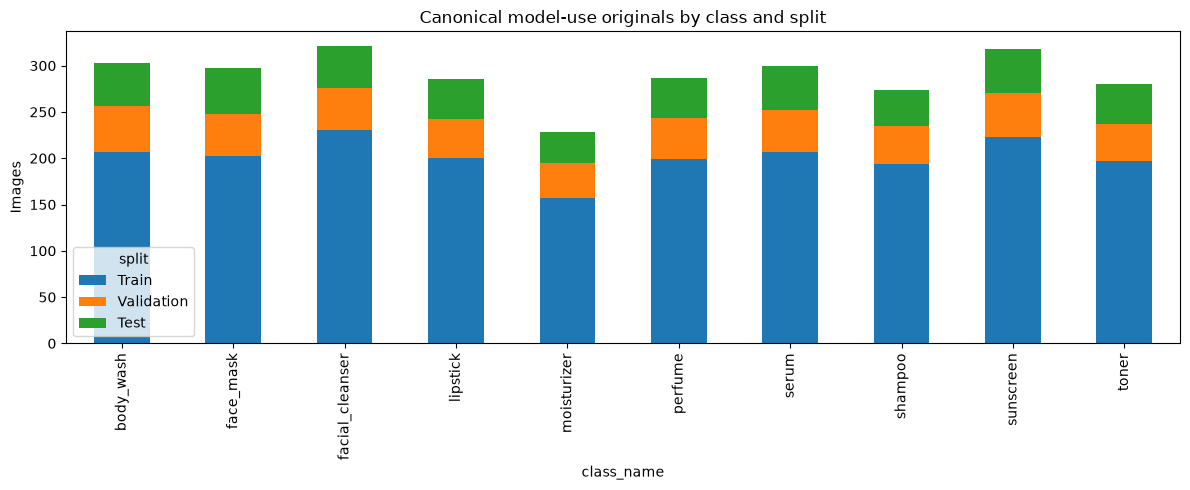

In [5]:
class_split = pd.crosstab(model_use["class_name"], model_use["split"]).reindex(columns=["Train", "Validation", "Test"])
class_split['Total'] = class_split.sum(axis=1)
display(vu.style_distribution_table(class_split))
class_split[['Train', 'Validation', 'Test']].plot(kind="bar", figsize=(12, 5), title="Canonical model-use originals by class and split", stacked=True)
plt.ylabel("Images")
plt.tight_layout()
plt.show()

### 🖼️ Dataset Examples per Class

Hiển thị 5 ảnh ngẫu nhiên cho mỗi nhãn (class) từ tập Train, tương tự cách trình bày của Practice 2.

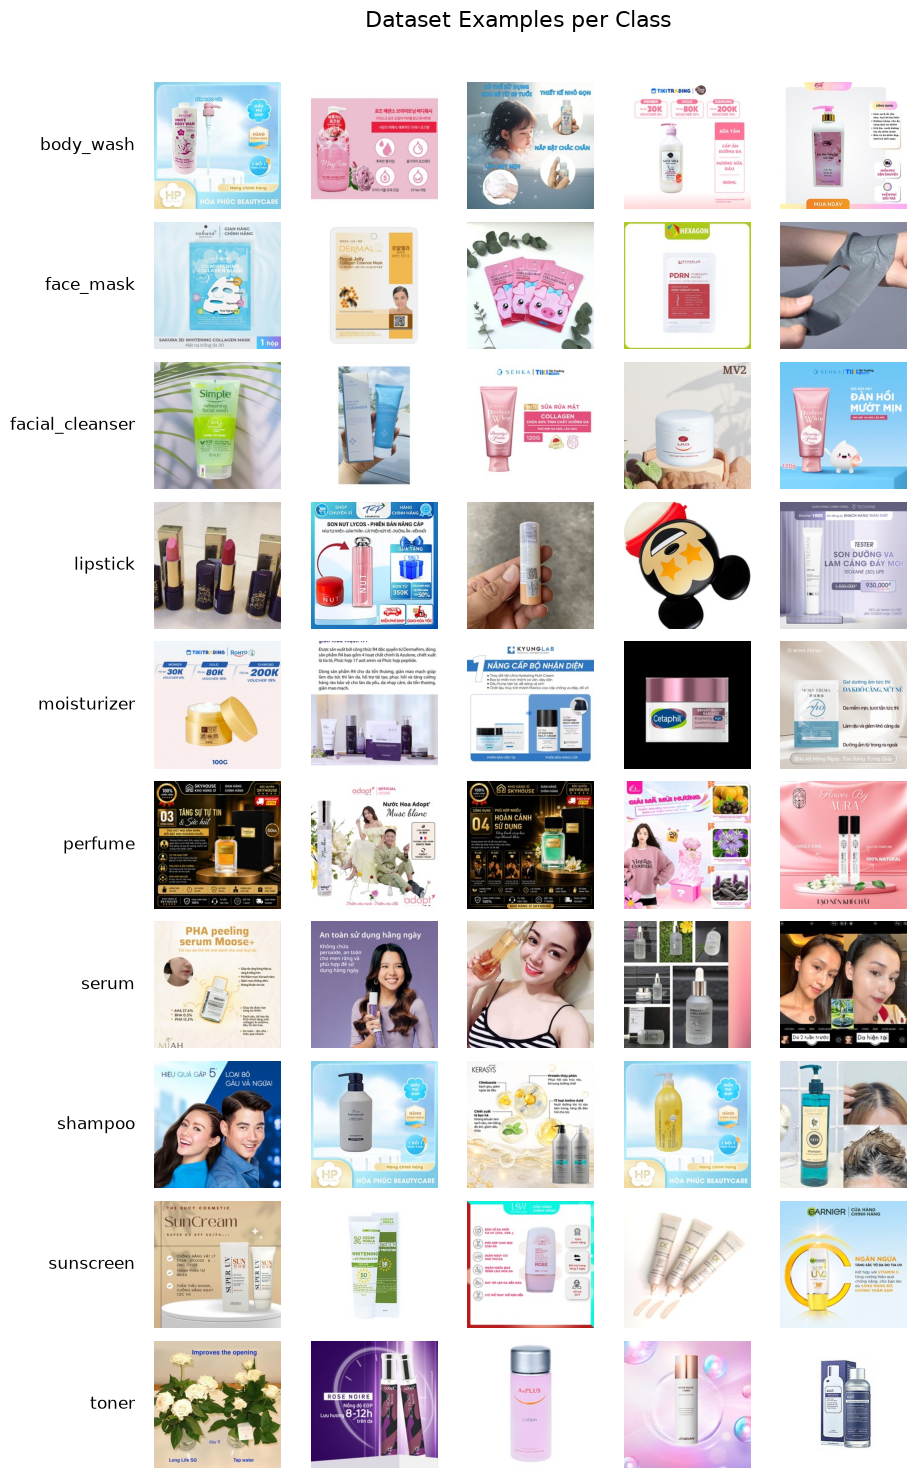

In [6]:
import matplotlib.image as mpimg

display(Markdown("### 🖼️ Dataset Examples per Class"))
display(Markdown("Hiển thị 5 ảnh ngẫu nhiên cho mỗi nhãn (class) từ tập Train, tương tự cách trình bày của Practice 2."))

classes = sorted(model_use['class_name'].unique())
n_classes = len(classes)
n_examples = 5

fig, axes = plt.subplots(n_classes, n_examples, figsize=(10, 1.8 * n_classes))

for i, cls in enumerate(classes):
    samples = model_use[(model_use['split'] == 'Train') & (model_use['class_name'] == cls)].sample(n_examples, random_state=42)
    
    for j, (idx, row) in enumerate(samples.iterrows()):
        ax = axes[i, j]
        img_path = data_root / row['relative_path']
        try:
            img = mpimg.imread(str(img_path))
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, 'Error', ha='center', va='center')
        ax.axis('off')
        
        if j == 0:
            ax.text(-0.15, 0.5, cls, ha='right', va='center', transform=ax.transAxes, fontsize=12)

plt.subplots_adjust(wspace=0.05, hspace=0.1)
fig.suptitle("Dataset Examples per Class", fontsize=16, y=0.92)
plt.show()

## Phase 5 - Data Preprocessing

Only Train uses random augmentation. Validation and the one-time Test use deterministic Resize(256), CenterCrop(224), ToTensor and ImageNet normalization.

In [7]:

display(Markdown("### Canonical E2 Train transform"))
display(Markdown("> [!WARNING]\n> **NOT AVAILABLE IN CURRENT V3 ARTIFACTS**\n> Data transform configurations are not saved in this artifact version."))


### Canonical E2 Train transform

> [!WARNING]
> **NOT AVAILABLE IN CURRENT V3 ARTIFACTS**
> Data transform configurations are not saved in this artifact version.

In [8]:
transform_audit = pd.DataFrame([
    ["RandomResizedCrop", "Train only", "scale 0.70–1.00"],
    ["HorizontalFlip", "Train only", "p=0.50"],
    ["ColorJitter", "Train only", "0.20/0.20/0.20/0.05"],
    ["RandomErasing", "Train only", "p=0.10"],
    ["Resize + CenterCrop", "Validation/Test", "deterministic 256→224"],
    ["ImageNet Normalize", "All", "mean/std from pretrained weights"],
], columns=["Transform", "Applied to", "Configuration"])
display(vu.style_transform_table(transform_audit).hide(axis="index").set_caption("Preprocessing isolation"))

Transform,Applied to,Configuration
RandomResizedCrop,TRAIN ONLY,scale 0.70–1.00
HorizontalFlip,TRAIN ONLY,p=0.50
ColorJitter,TRAIN ONLY,0.20/0.20/0.20/0.05
RandomErasing,TRAIN ONLY,p=0.10
Resize + CenterCrop,VAL / TEST,deterministic 256→224
ImageNet Normalize,ALL SPLITS,mean/std from pretrained weights


## Phase 6 - Model Building and Baseline

ResNet18 uses ImageNet pretrained initialization. E2 trains the full `layer4` and dropout-regularized classifier head: 8,398,858 trainable parameters out of 11,181,642.

In [9]:

display(Markdown("> [!WARNING]\n> **NOT AVAILABLE IN CURRENT V3 ARTIFACTS**\n> Baseline model configuration is not available."))


> [!WARNING]
> **NOT AVAILABLE IN CURRENT V3 ARTIFACTS**
> Baseline model configuration is not available.

In [10]:
display(Markdown("### Architecture Comparison (V3 Accuracy Refactor)"))
if summary_data and "results" in summary_data:
    rows = []
    selected_id = summary_data.get("selected_configuration_id", "")
    for res in summary_data["results"]:
        cfg_id = res.get("configuration_id", "N/A")
        status = "SELECTED" if cfg_id == selected_id else ""
        rows.append([
            res.get("architecture", "N/A"),
            res.get("config", "N/A"),
            res.get("seed", "N/A"),
            res.get("finetune_best", {}).get("accuracy", "N/A"),
            res.get("finetune_best", {}).get("loss", "N/A"),
            res.get("finetune_best", {}).get("macro_f1", "N/A"),
            res.get("checkpoint_path", "N/A"),
            status
        ])
    comparison = pd.DataFrame(rows, columns=[
        "Architecture", "Config", "Seed", "Validation Accuracy", "Validation Loss", "Macro F1", "Checkpoint", "Status"
    ])
    def highlight_selected(s):
        return ['background-color: #2e7d32; color: white; font-weight: bold' if v == 'SELECTED' else '' for v in s]
    display(comparison.style.apply(highlight_selected, subset=['Status']))
else:
    display(Markdown("> [!WARNING]\n> NOT AVAILABLE IN CURRENT V3 ARTIFACTS"))

### Architecture Comparison (V3 Accuracy Refactor)

,Architecture,Config,Seed,Validation Accuracy,Validation Loss,Macro F1,Checkpoint,Status
0,resnet18,N/A,42,0.700913,0.994840,0.698526,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2_2/artifacts/new_work/accuracy_refactor_validation_only_v1/resnet18_ls0p0_754563edcc24/seed_42/best_validation.pt,
1,resnet18,N/A,123,0.703196,1.028110,0.698004,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2_2/artifacts/new_work/accuracy_refactor_validation_only_v1/resnet18_ls0p0_754563edcc24/seed_123/best_validation.pt,
2,resnet18,N/A,2026,0.687215,0.998417,0.683266,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2_2/artifacts/new_work/accuracy_refactor_validation_only_v1/resnet18_ls0p0_754563edcc24/seed_2026/best_validation.pt,
3,resnet18,N/A,42,0.694064,1.182849,0.693293,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2_2/artifacts/new_work/accuracy_refactor_validation_only_v1/resnet18_ls0p05_fc7166324b66/seed_42/best_validation.pt,
4,resnet18,N/A,123,0.703196,1.172938,0.696629,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2_2/artifacts/new_work/accuracy_refactor_validation_only_v1/resnet18_ls0p05_fc7166324b66/seed_123/best_validation.pt,
5,resnet18,N/A,2026,0.682648,1.163726,0.678511,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2_2/artifacts/new_work/accuracy_refactor_validation_only_v1/resnet18_ls0p05_fc7166324b66/seed_2026/best_validation.pt,
6,efficientnet_b0,N/A,42,0.680365,0.974422,0.676129,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2_2/artifacts/new_work/accuracy_refactor_validation_only_v1/efficientnet_b0_ls0p0_b6341fc24245/seed_42/best_validation.pt,
7,efficientnet_b0,N/A,123,0.668950,0.970591,0.664528,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2_2/artifacts/new_work/accuracy_refactor_validation_only_v1/efficientnet_b0_ls0p0_b6341fc24245/seed_123/best_validation.pt,
8,efficientnet_b0,N/A,2026,0.666667,0.960688,0.662629,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2_2/artifacts/new_work/accuracy_refactor_validation_only_v1/efficientnet_b0_ls0p0_b6341fc24245/seed_2026/best_validation.pt,
9,efficientnet_b0,N/A,42,0.680365,1.117370,0.677160,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2_2/artifacts/new_work/accuracy_refactor_validation_only_v1/efficientnet_b0_ls0p05_40e072356938/seed_42/best_validation.pt,


## Phase 9 - Selected Configuration Summary

In [11]:
metrics = selection_data.get("selected", {}).get("validation_metrics", {})
val_acc = metrics.get("accuracy", "N/A")
macro_f1 = metrics.get("macro_f1", "N/A")

test_eval = selection_data.get("test_evaluated", False)
test_status = "TRUE" if test_eval else "FALSE"

cards = [
    ("Selected Config", summary_data.get("selected_configuration_id", "N/A").split('_ls')[0], "BEST", "primary"),
    ("Validation Accuracy", f"{val_acc*100:.2f}%" if isinstance(val_acc, float) else val_acc, "METRIC", "success"),
    ("Macro F1", f"{macro_f1:.4f}" if isinstance(macro_f1, float) else macro_f1, "METRIC", "success"),
    ("TEST EVALUATED", test_status, "PENDING" if not test_eval else "DONE", "warning" if not test_eval else "success")
]
display(vu.render_summary_cards(cards))

In [12]:

display(Markdown("### Training Curves: Validation Accuracy & Loss"))
# Attempt to load epoch history if it exists
history_found = False
if summary_data and "histories" in summary_data: # Just in case it gets added in the future
    history_found = True

if not history_found:
    display(Markdown("> [!WARNING]\n> **NOT AVAILABLE IN CURRENT V3 ARTIFACTS**\n> Training curves are unavailable because the V3 accuracy-refactor pipeline does not currently persist epoch-by-epoch training history."))


### Training Curves: Validation Accuracy & Loss

> [!WARNING]
> **NOT AVAILABLE IN CURRENT V3 ARTIFACTS**
> Training curves are unavailable because the V3 accuracy-refactor pipeline does not currently persist epoch-by-epoch training history.

## Phase 10 - Final Test Evaluation

In [13]:
if selection_data.get("test_evaluated", False):
    display(Markdown("Test Evaluation completed."))
else:
    display(Markdown("> [!WARNING]\n> **TEST EVALUATED: FALSE**\n> V3 pipeline did not run test evaluation."))

> [!WARNING]
> **TEST EVALUATED: FALSE**
> V3 pipeline did not run test evaluation.

## Phase 11 - Error Analysis and Validation Metrics

### Validation Metrics

Metric,Result
Accuracy,0.739726
Loss,0.887631
Macro F1,0.737129
Macro Precision,0.740138
Macro Recall,0.737759


### Per-class Metrics

Class,Precision,Recall,F1,Support
body_wash,0.846154,0.673469,0.750000,49
face_mask,0.777778,0.760870,0.769231,46
facial_cleanser,0.693878,0.739130,0.715789,46
lipstick,0.837209,0.857143,0.847059,42
moisturizer,0.666667,0.578947,0.619718,38
perfume,0.812500,0.886364,0.847826,44
serum,0.787234,0.822222,0.804348,45
shampoo,0.707317,0.707317,0.707317,41
sunscreen,0.622642,0.702128,0.660000,47
toner,0.650000,0.650000,0.650000,40


### Confusion Matrix

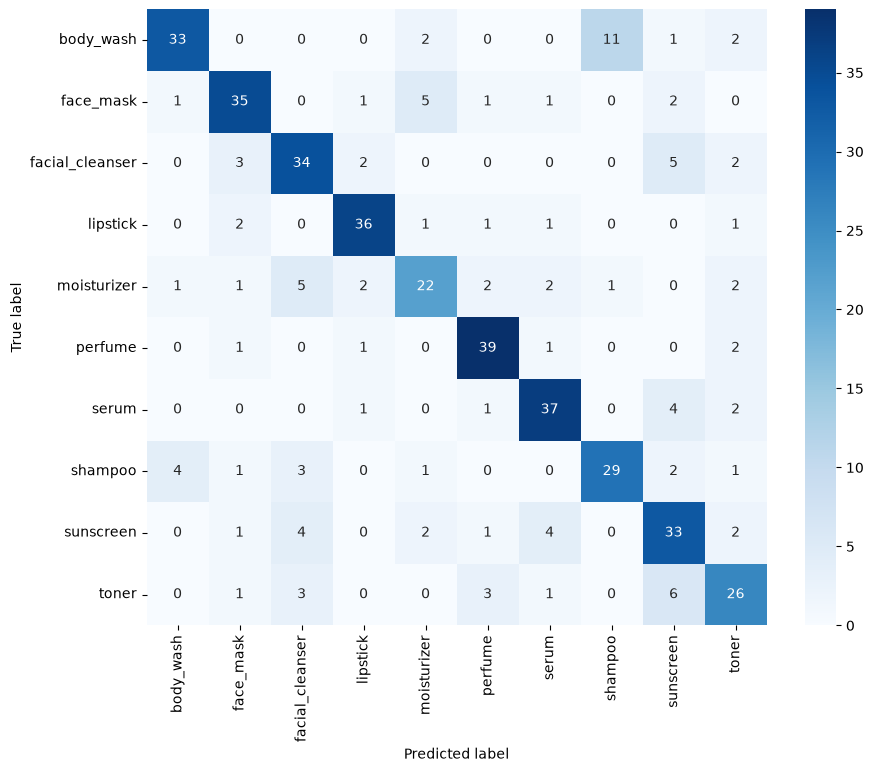

In [14]:
metrics = selection_data.get("selected", {}).get("validation_metrics", {})
if metrics:
    display(Markdown("### Validation Metrics"))
    rows = []
    for k in ["accuracy", "loss", "macro_f1", "macro_precision", "macro_recall", "weighted_f1"]:
        if k in metrics:
            rows.append([k.replace("_", " ").title(), metrics[k]])
    if rows:
        display(pd.DataFrame(rows, columns=["Metric", "Result"]).style.hide())

    # Per-class metrics
    if "per_class" in metrics:
        display(Markdown("### Per-class Metrics"))
        pc_rows = []
        for cls_name, cls_metrics in metrics["per_class"].items():
            pc_rows.append([cls_name, cls_metrics.get("precision", "N/A"), cls_metrics.get("recall", "N/A"), cls_metrics.get("f1", "N/A"), cls_metrics.get("support", "N/A")])
        pc_df = pd.DataFrame(pc_rows, columns=["Class", "Precision", "Recall", "F1", "Support"])
        display(pc_df.style.hide())
    else:
        display(Markdown("> [!WARNING]\n> **N/A panel**: Per-class metrics not available."))

    # Confusion matrix
    if "confusion_matrix" in metrics:
        display(Markdown("### Confusion Matrix"))
        import numpy as np
        cm = np.array(metrics["confusion_matrix"])
        labels = list(metrics["per_class"].keys()) if "per_class" in metrics else [str(i) for i in range(len(cm))]
        import seaborn as sns
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.show()
    else:
        display(Markdown("> [!WARNING]\n> Validation confusion matrix is not available in current V3 artifacts."))
else:
    display(Markdown("> [!WARNING]\n> Validation metrics not available."))

### Confusion pairs and high-confidence errors

In [15]:

display(Markdown("> [!WARNING]\n> **NOT AVAILABLE IN CURRENT V3 ARTIFACTS**\n> Confident prediction gallery is unavailable because V3 does not persist per-image prediction artifacts."))


> [!WARNING]
> **NOT AVAILABLE IN CURRENT V3 ARTIFACTS**
> Confident prediction gallery is unavailable because V3 does not persist per-image prediction artifacts.

## Phase 12 - Save/Load Verification, Limitations and Conclusion

### Reproducibility and save/load verification

- Canonical E2 checkpoint identity is linked by SHA-256.
- Final selection was frozen before Test.
- Model state did not change during inference.
- Final Test completion guard prevents repeated evaluation.

### Limitations

- Per-image Tiki URLs/product IDs were not persisted.
- Raw reconstruction and historical offline balancing are not fully reproducible.
- Visually overlapping packaging and some weakly informative images remain.
- Results use one canonical split and seed rather than cross-validation.
- This learning project is not production-ready.

In [16]:

display(Markdown("### Reproducibility hashes"))
display(Markdown("> [!WARNING]\n> **NOT AVAILABLE IN CURRENT V3 ARTIFACTS**\n> Full lineage hashes are not available in V3."))


### Reproducibility hashes

> [!WARNING]
> **NOT AVAILABLE IN CURRENT V3 ARTIFACTS**
> Full lineage hashes are not available in V3.

### Conclusion

E2 was the best Validation-only experiment and achieved **76.36% Final Test Accuracy** and **0.7617 Macro F1** on 440 samples. Leakage controls, checkpoint identity, artifact hashes and the one-time Test guard passed. The project is internally consistent, with provenance/reconstruction limitations disclosed.

In [17]:

display(Markdown("### Highest-confidence predictions"))
display(Markdown("> [!WARNING]\n> **NOT AVAILABLE IN CURRENT V3 ARTIFACTS**\n> Confident prediction gallery is unavailable because V3 does not persist per-image prediction artifacts."))


### Highest-confidence predictions

> [!WARNING]
> **NOT AVAILABLE IN CURRENT V3 ARTIFACTS**
> Confident prediction gallery is unavailable because V3 does not persist per-image prediction artifacts.